# Schnakenberg Analysis

In this notebook, we study the Schnakenberg reaction–diffusion system from the perspective of diffusion-driven instability.

The aim is to understand when a homogeneous steady state becomes unstable after diffusion is introduced, leading to the formation of Turing patterns. This is done by examining the linearised system, the associated Jacobian, and the growth of spatial perturbation modes.

In particular, we:
- visualise the parameter regions where Turing instability can occur,
- compute the homogeneous steady state,
- examine the nullclines and fixed point,
- analyse the Jacobian and eigenvalues,
- study the dispersion relation as a function of spatial wavenumber,
- and identify the unstable band of modes.

We begin with the parameter-space picture, since this gives a useful overview of where pattern formation is expected before focusing on a specific parameter choice.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src.analysis_tools.derivatives import schnakenberg_derivatives
from src.analysis_tools.turing import (
    compute_turing_mask,
    trace_det,
    turing_conditions,
    critical_diffusion_ratio,
    h_k2,
    dominant_lambda_k2,
    unstable_k2_band,
)
from src.visualiser.phase_plane import plot_phase_plane
from src.visualiser.turing_relation import plot_turing_relation

## 1. Parameter-space exploration

Before fixing a particular choice of parameters, we first examine where Turing instability is possible in the \((a,b)\)-parameter space.

For the Schnakenberg model,

$$f(u,v)=a-u+u^2v, \qquad g(u,v)=b-u^2v,$$

the homogeneous steady state is

$$u_0=a+b, \qquad v_0=\frac{b}{(a+b)^2}.$$

At each point \((a,b)\), we evaluate the Jacobian at the steady state and check whether the system is stable without diffusion but unstable for at least one spatial mode after diffusion is introduced.

The contours below show the boundary of the Turing-unstable region for different diffusion ratios $d$.

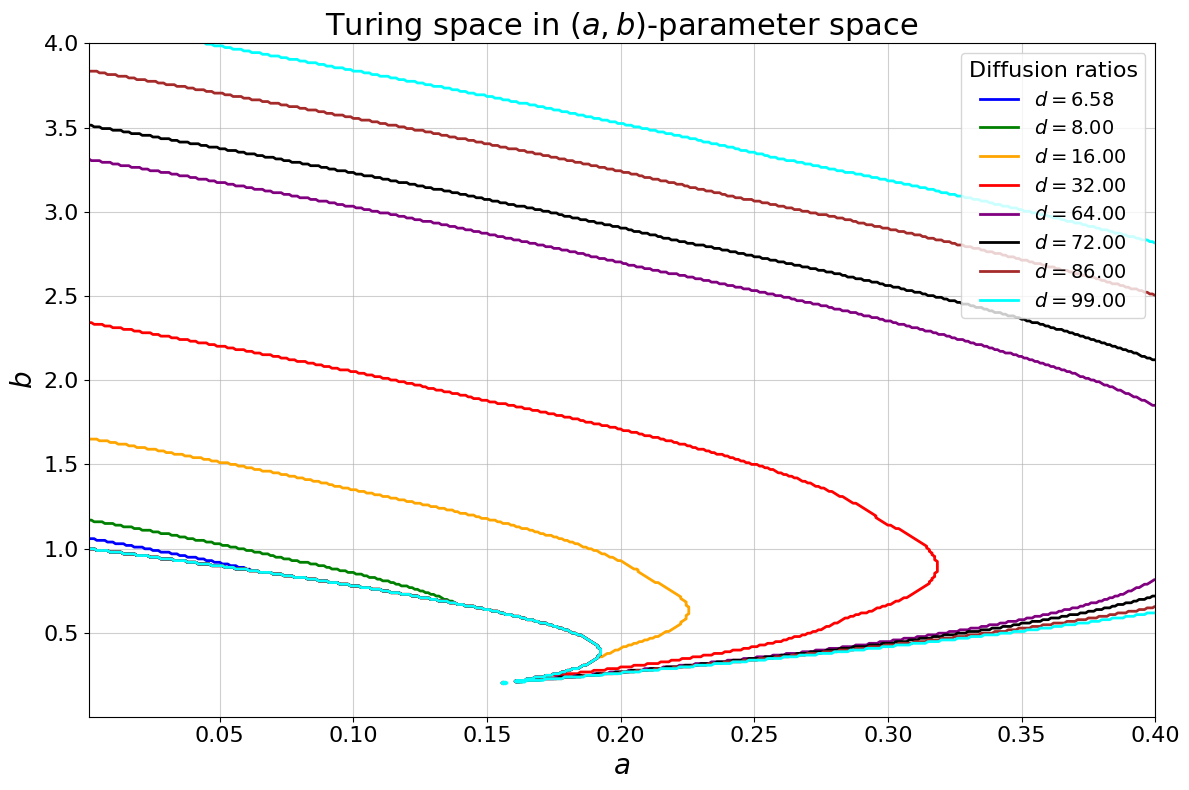

In [3]:
# Parameter grid
a_vals = np.linspace(0.001, 0.4, 400)
b_vals = np.linspace(0.001, 4.0, 400)
A, B = np.meshgrid(a_vals, b_vals)

# Diffusion ratios
d_values = [6.58, 8, 16, 32, 64, 72, 86, 99]
colors = ["blue", "green", "orange", "red", "purple", "black", "brown", "cyan"]

# Wavenumber range
k2_vals = np.linspace(0.01, 10, 100)

plt.figure(figsize=(12, 8))
legend_elements = []

for d_val, color in zip(d_values, colors):
    mask = compute_turing_mask(A, B, d_val, k2_vals, schnakenberg_derivatives)

    plt.contour(A, B, mask, levels=[0.5], colors=color, linewidths=2)

    legend_elements.append(
        Line2D([0], [0], color=color, lw=2, label=fr"$d = {d_val:.2f}$")
    )

plt.xlabel(r"$a$", fontsize=20)
plt.ylabel(r"$b$", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, alpha=0.6)
plt.title(r"Turing space in $(a,b)$-parameter space", fontsize=22)

plt.legend(
    handles=legend_elements,
    title="Diffusion ratios",
    fontsize=14,
    title_fontsize=16,
    loc="upper right",
)

plt.tight_layout()
plt.show()

## 2. Choosing a representative parameter set

From the parameter-space plot, we now choose a representative Schnakenberg parameter set that lies inside a Turing-unstable region.

For the rest of this notebook, we use

$$a = 0.1, \qquad b = 0.9, \qquad \gamma = 2.$$

We then compute the homogeneous steady state and analyse its stability with and without diffusion.

In [4]:
# Representative parameter set
a = 0.1
b = 0.9
gamma = 2.0
d = 20.0

# Homogeneous steady state
u0 = a + b
v0 = b / (a + b)**2

print("Chosen parameters:")
print(f"a     = {a:.4f}")
print(f"b     = {b:.4f}")
print(f"gamma = {gamma:.4f}")
print(f"d     = {d:.4f}")

print("\nHomogeneous steady state:")
print(f"u0 = {u0:.4f}")
print(f"v0 = {v0:.4f}")

Chosen parameters:
a     = 0.1000
b     = 0.9000
gamma = 2.0000
d     = 20.0000

Homogeneous steady state:
u0 = 1.0000
v0 = 0.9000


## 3. Nullclines and fixed point

Before introducing diffusion, we first examine the reaction kinetics of the spatially homogeneous system.

For the Schnakenberg model,

$$
f(u,v)=a-u+u^2v, \qquad g(u,v)=b-u^2v,
$$

the nullclines are given by

$$f(u,v)=0 \quad \Rightarrow \quad v=\frac{u-a}{u^2},$$

and


$$g(u,v)=0 \quad \Rightarrow \quad v=\frac{b}{u^2}.$$

Their intersection gives the homogeneous steady state.

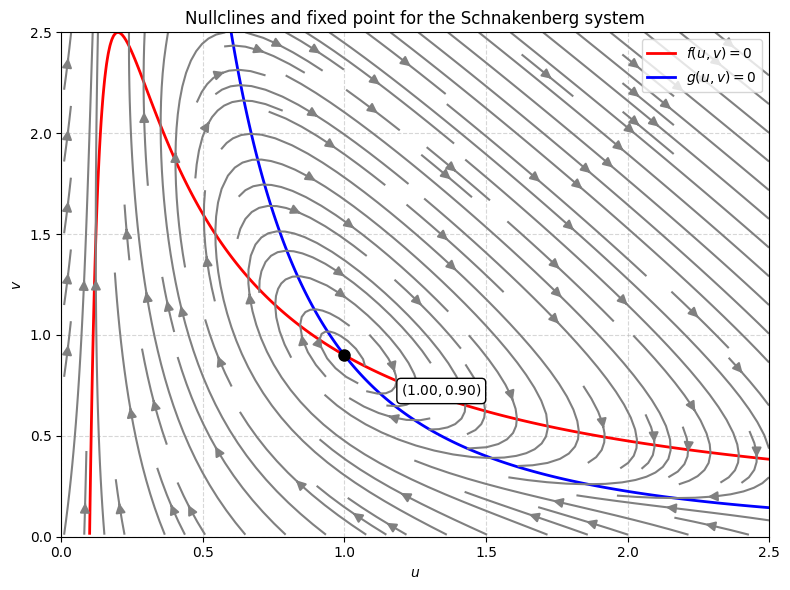

In [5]:
def f_phase(u, v):
    return a - u + u**2 * v

def g_phase(u, v):
    return b - u**2 * v

plot_phase_plane(
    f=f_phase,
    g=g_phase,
    u0=u0,
    v0=v0,
    u_range=(0.01, 2.5),
    v_range=(0.01, 2.5),
    title="Nullclines and fixed point for the Schnakenberg system"
)

## 4. Jacobian and local stability

We now linearise the reaction terms around the homogeneous steady state. For the Schnakenberg system, the Jacobian is

$
J =
\begin{pmatrix}
f_u & f_v \\
g_u & g_v
\end{pmatrix}.
$

Evaluating this matrix at $(u_0,v_0)$ allows us to check whether the steady state is stable in the absence of diffusion. Stability requires

$$
\operatorname{tr}(J) < 0, \qquad \det(J) > 0
$$

In [6]:
fu, fv, gu, gv = schnakenberg_derivatives(a, b)

J = np.array([
    [fu, fv],
    [gu, gv]
])

trJ, detJ = trace_det(fu, fv, gu, gv)
eigvals = np.linalg.eigvals(J)

print("Jacobian at steady state:")
print(J)

print("\nTrace and determinant:")
print(f"tr(J)  = {trJ:.4f}")
print(f"det(J) = {detJ:.4f}")

print("\nEigenvalues:")
for i, eig in enumerate(eigvals, start=1):
    print(f"lambda_{i} = {eig:.4f}")

print("\nStable without diffusion?")
print(trJ < 0 and detJ > 0)

Jacobian at steady state:
[[ 0.8  1. ]
 [-1.8 -1. ]]

Trace and determinant:
tr(J)  = -0.2000
det(J) = 1.0000

Eigenvalues:
lambda_1 = -0.1000+0.9950j
lambda_2 = -0.1000-0.9950j

Stable without diffusion?
True


## 5. Dispersion relation and unstable modes

To understand which spatial modes grow after diffusion is introduced, we study the dispersion relation. The function $h(k^2)$ determines whether perturbations with wavenumber $k$ can become unstable.

When $h(k^2)<0$, the dominant eigenvalue becomes positive for a band of spatial modes, indicating diffusion-driven instability. We compare values of the diffusion ratio below, at, and above the critical threshold $d_c$.

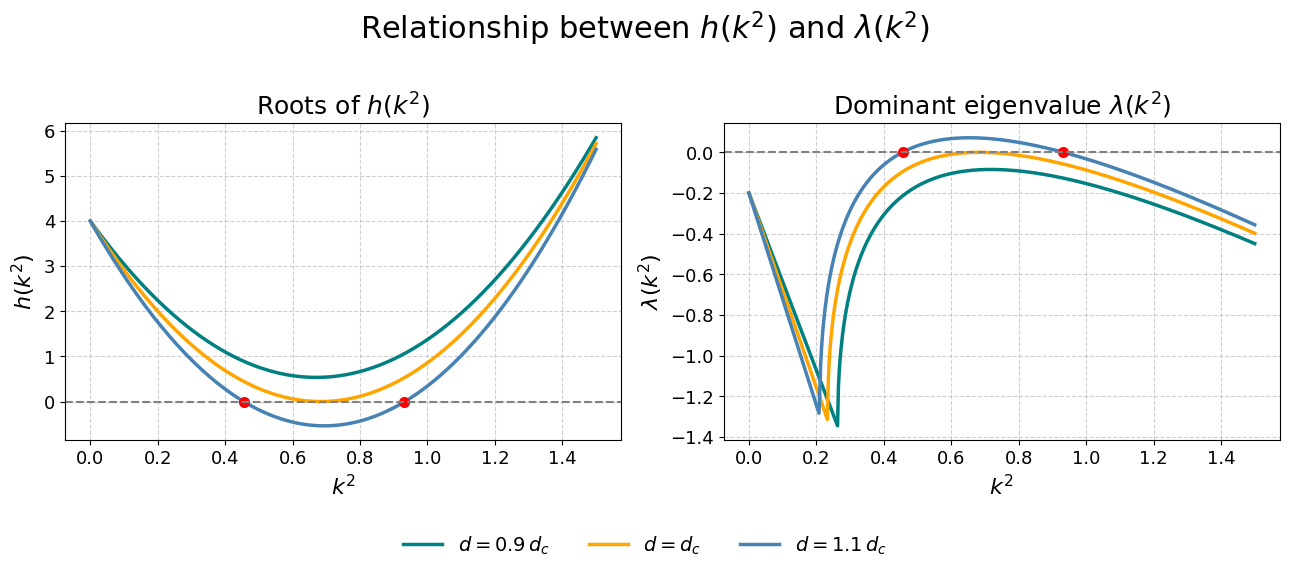

In [11]:
fu, fv, gu, gv = schnakenberg_derivatives(a, b)
dc = critical_diffusion_ratio(fu, fv, gu, gv)

d_vals = [0.9 * dc, dc, 1.1 * dc]
labels = [r"$d = 0.9\,d_c$", r"$d = d_c$", r"$d = 1.1\,d_c$"]
colors = ["teal", "orange", "steelblue"]

k2_vals = np.linspace(0, 1.5, 600)

plot_turing_relation(
    k2_vals=k2_vals,
    fu=fu,
    fv=fv,
    gu=gu,
    gv=gv,
    gamma=gamma,
    d_vals=d_vals,
    labels=labels,
    colors=colors,
)

## 6. Conclusion

For the Schnakenberg system, the homogeneous steady state is stable in the absence of diffusion, satisfying
$$
\operatorname{tr}(J) < 0, \qquad \det(J) > 0.
$$

The dispersion relation shows that, for sufficiently large diffusion ratio $d$, a band of spatial modes becomes unstable. This confirms the presence of a classical diffusion-driven (Turing) instability.

The Schnakenberg model therefore provides a clean and analytically tractable example of pattern formation arising purely from the interaction between reaction kinetics and differential diffusion.